Show block layout for both normal blocks and Exec Maisonette upper lower block floorplan

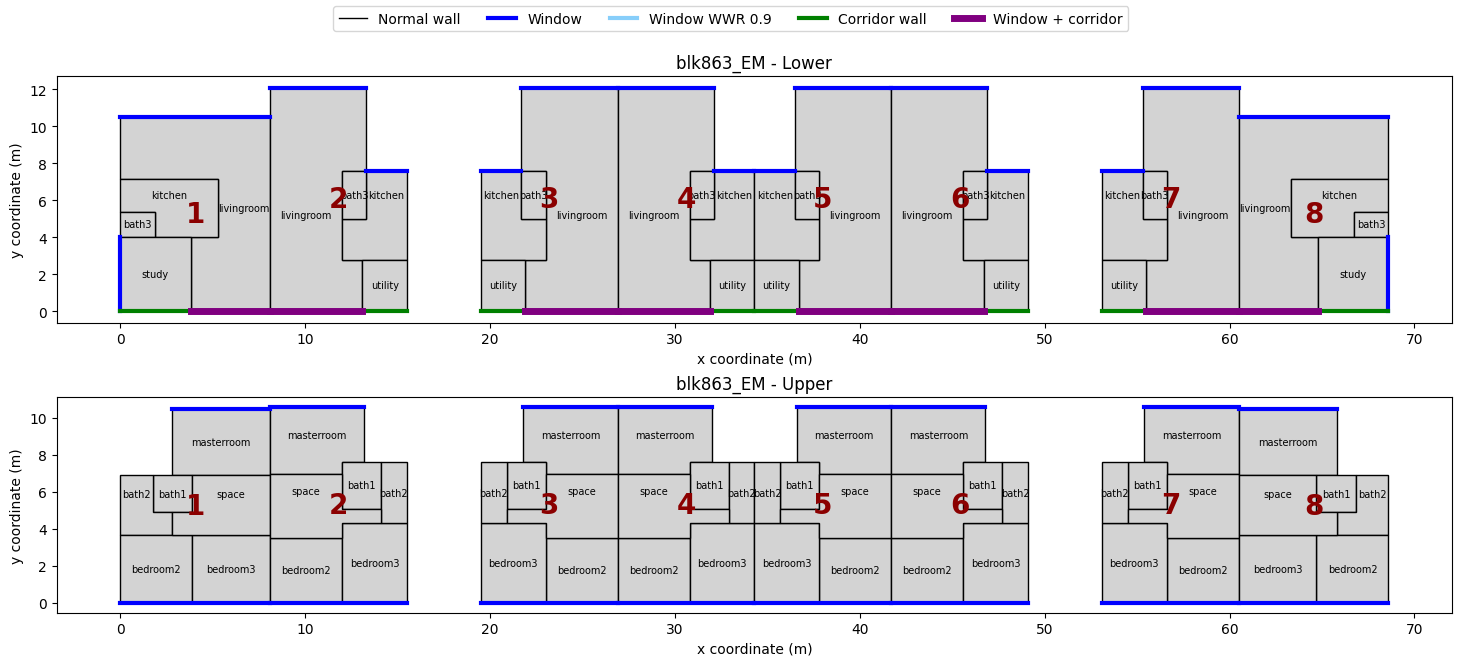

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon


INPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863_EM.json")


def bounds(rooms):
    points = [p for room in rooms.values() for p in room["coordinates"]]
    xs, ys = zip(*points)
    return min(xs), max(xs), min(ys), max(ys)


def facade_points(facade):
    if "points" in facade:
        return facade["points"]
    return [facade["start"], facade["end"]]


def facade_segments(facades, facade_type):
    segments = []

    for facade in facades:
        if facade.get("type", "").lower() != facade_type:
            continue

        points = facade_points(facade)

        segments.extend(
            (points[i], points[i + 1])
            for i in range(len(points) - 1)
        )

    return segments


def cross(a, b, c):
    return (
        (b[0] - a[0]) * (c[1] - a[1])
        - (b[1] - a[1]) * (c[0] - a[0])
    )


def segment_overlap(segment_a, segment_b, tolerance=1e-9):
    a, b = segment_a
    c, d = segment_b

    vx = b[0] - a[0]
    vy = b[1] - a[1]

    length_squared = vx * vx + vy * vy

    if length_squared <= tolerance:
        return None

    if (
        abs(cross(a, b, c)) > tolerance
        or abs(cross(a, b, d)) > tolerance
    ):
        return None

    wx = d[0] - c[0]
    wy = d[1] - c[1]

    if abs(vx * wy - vy * wx) > tolerance:
        return None

    c_position = (
        (c[0] - a[0]) * vx
        + (c[1] - a[1]) * vy
    ) / length_squared

    d_position = (
        (d[0] - a[0]) * vx
        + (d[1] - a[1]) * vy
    ) / length_squared

    start_position = max(
        0,
        min(c_position, d_position)
    )

    end_position = min(
        1,
        max(c_position, d_position)
    )

    if end_position - start_position <= tolerance:
        return None

    return (
        [
            a[0] + vx * start_position,
            a[1] + vy * start_position
        ],
        [
            a[0] + vx * end_position,
            a[1] + vy * end_position
        ],
    )


def overlapping_segments(window_segments, corridor_segments):
    overlaps = []

    for window_segment in window_segments:
        for corridor_segment in corridor_segments:

            overlap = segment_overlap(
                window_segment,
                corridor_segment
            )

            if overlap:
                overlaps.append(overlap)

    return overlaps


def plot_segment(ax, segment, color, linewidth, zorder):
    (x1, y1), (x2, y2) = segment

    ax.plot(
        [x1, x2],
        [y1, y2],
        color=color,
        linewidth=linewidth,
        zorder=zorder
    )


def plot_units(ax, units, title):

    for unit_number, unit in units.items():

        if unit_number == "numberStories":
            continue

        rooms = unit["rooms"]

        for room_name, room in rooms.items():
            coordinates = room["coordinates"]

            ax.add_patch(
                Polygon(
                    coordinates,
                    closed=True,
                    facecolor=(
                        "white"
                        if room_name.lower() == "balcony"
                        else "lightgray"
                    ),
                    edgecolor="black",
                    linewidth=1,
                )
            )

            point = ShapelyPolygon(
                coordinates
            ).representative_point()

            ax.text(
                point.x,
                point.y,
                room_name,
                ha="center",
                va="center",
                fontsize=7,
            )

        facades = unit.get("facades", [])

        window_segments = facade_segments(
            facades,
            "window"
        )

        corridor_segments = facade_segments(
            facades,
            "corridor"
        )

        for facade in facades:

            if facade.get("type", "").lower() != "window":
                continue

            segments = facade_segments(
                [facade],
                "window"
            )

            color = (
                "lightskyblue"
                if facade.get("WWR") == 0.9
                else "blue"
            )

            for segment in segments:
                plot_segment(
                    ax,
                    segment,
                    color=color,
                    linewidth=3,
                    zorder=5
                )

        for segment in corridor_segments:
            plot_segment(
                ax,
                segment,
                color="green",
                linewidth=3,
                zorder=5
            )

        for segment in overlapping_segments(
            window_segments,
            corridor_segments
        ):
            plot_segment(
                ax,
                segment,
                color="purple",
                linewidth=5,
                zorder=7
            )

        min_x, max_x, min_y, max_y = bounds(
            rooms
        )

        ax.text(
            (min_x + max_x) / 2,
            (min_y + max_y) / 2,
            unit_number,
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            color="darkred",
            zorder=6,
        )

    ax.set_aspect("equal")
    ax.autoscale()
    ax.margins(0.05)
    ax.set_xlabel("x coordinate (m)")
    ax.set_ylabel("y coordinate (m)")
    ax.set_title(title)
    ax.grid(False)


with INPUT_JSON.open(encoding="utf-8") as file:
    data = json.load(file)


# ------------------------------------------------------------
# EM layout: plot lower and upper separately
# ------------------------------------------------------------

if "EM" in INPUT_JSON.stem.upper():

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(18, 7)
    )

    plot_units(
        axes[0],
        data["lower"],
        f"{INPUT_JSON.stem} - Lower"
    )
    plot_units(
        axes[1],
        data["upper"],
        f"{INPUT_JSON.stem} - Upper"
    )

    fig.subplots_adjust(
        hspace=0.2,
        top=0.9,
        bottom=0.1
    )

else:

    fig, ax = plt.subplots(
        figsize=(16, 9)
    )

    plot_units(
        ax,
        data,
        f"{INPUT_JSON.stem} Floor Plan"
    )



fig.legend(
    handles=[
        Line2D(
            [0], [0],
            color="black",
            linewidth=1,
            label="Normal wall"
        ),
        Line2D(
            [0], [0],
            color="blue",
            linewidth=3,
            label="Window"
        ),
        Line2D(
            [0], [0],
            color="lightskyblue",
            linewidth=3,
            label="Window WWR 0.9"
        ),
        Line2D(
            [0], [0],
            color="green",
            linewidth=3,
            label="Corridor wall"
        ),
        Line2D(
            [0], [0],
            color="purple",
            linewidth=5,
            label="Window + corridor"
        ),
    ],
    loc="upper center",
    ncol=5
)

plt.show()

Checking unittemplates: show all rooms + window + corr

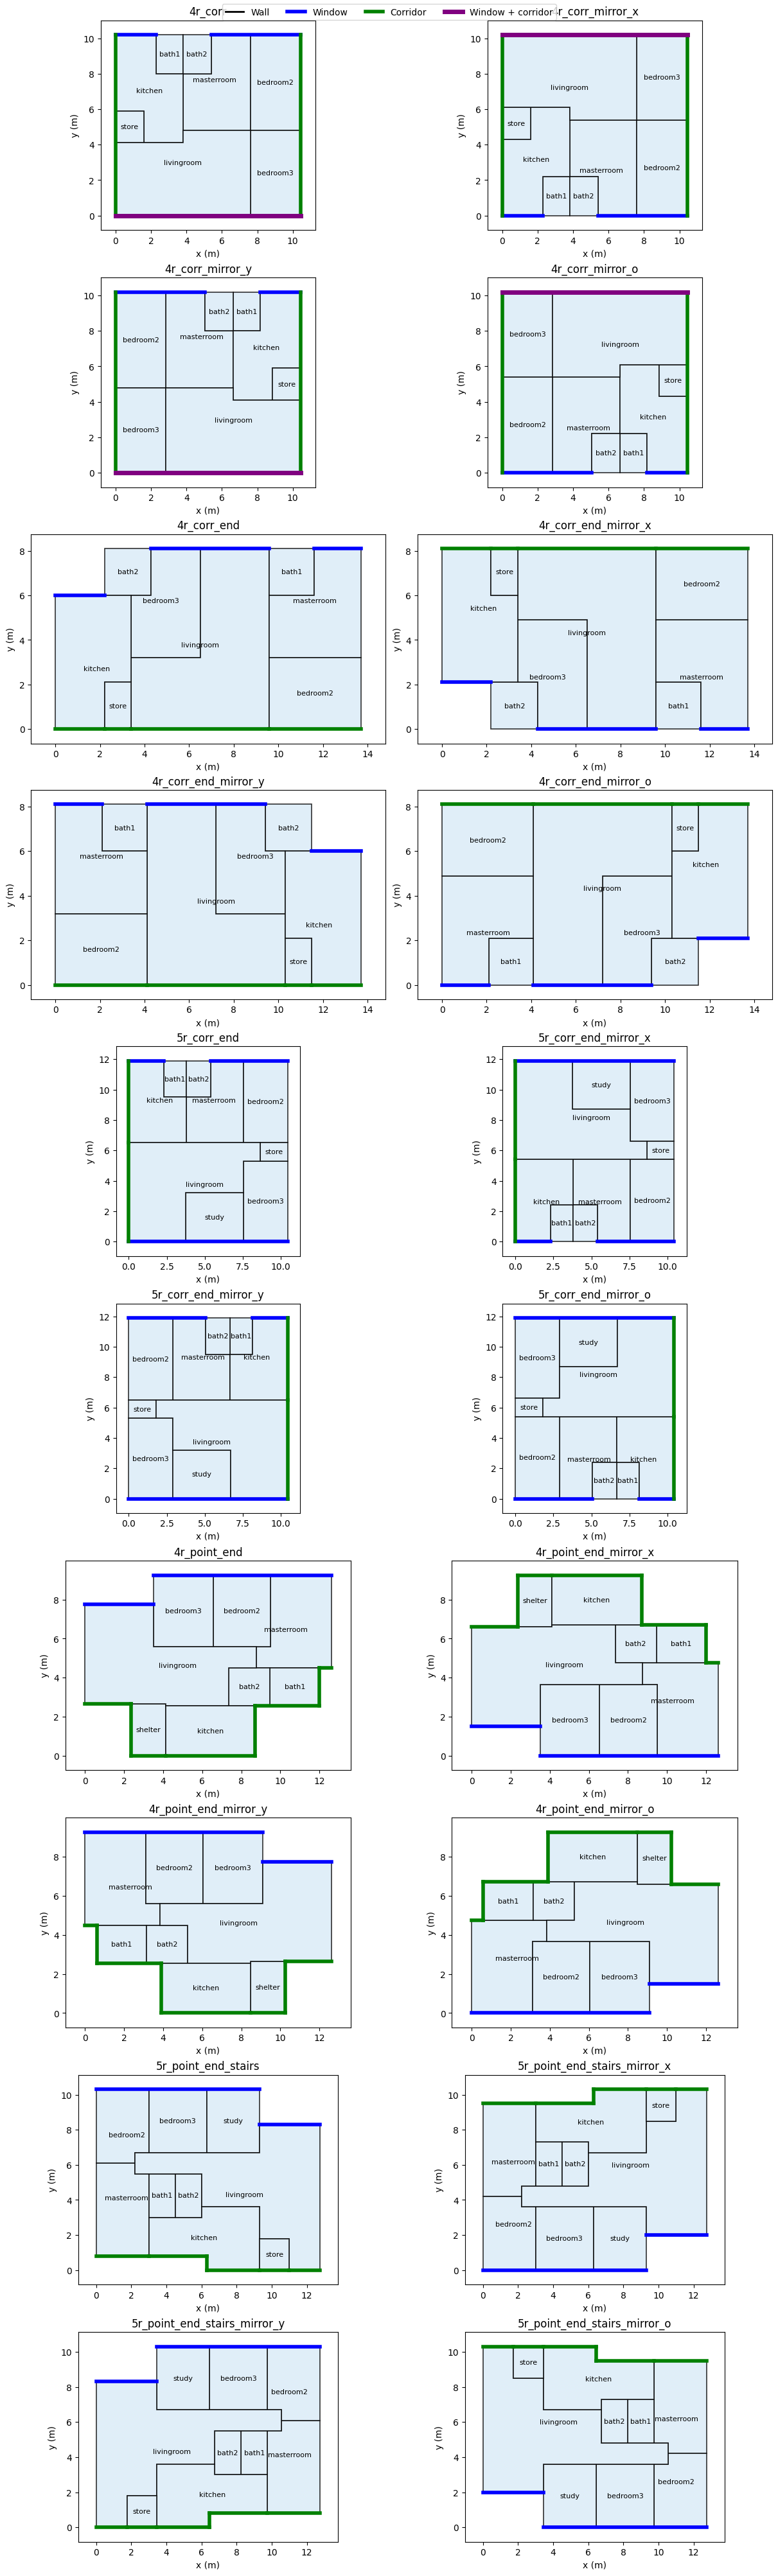

In [7]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon


def facade_points(facade):
    if "points" in facade:
        return facade["points"]
    return [facade["start"], facade["end"]]


def facade_segments(facades, facade_type):
    segments = []
    for facade in facades:
        if facade.get("type", "").lower() != facade_type:
            continue

        points = facade_points(facade)
        segments.extend((points[i], points[i + 1]) for i in range(len(points) - 1))

    return segments


def cross(a, b, c):
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def segment_overlap(segment_a, segment_b, tolerance=1e-9):
    a, b = segment_a
    c, d = segment_b

    vx = b[0] - a[0]
    vy = b[1] - a[1]
    length_squared = vx * vx + vy * vy

    if length_squared <= tolerance:
        return None

    if abs(cross(a, b, c)) > tolerance or abs(cross(a, b, d)) > tolerance:
        return None

    wx = d[0] - c[0]
    wy = d[1] - c[1]
    if abs(vx * wy - vy * wx) > tolerance:
        return None

    c_position = ((c[0] - a[0]) * vx + (c[1] - a[1]) * vy) / length_squared
    d_position = ((d[0] - a[0]) * vx + (d[1] - a[1]) * vy) / length_squared

    start_position = max(0, min(c_position, d_position))
    end_position = min(1, max(c_position, d_position))

    if end_position - start_position <= tolerance:
        return None

    return (
        [a[0] + vx * start_position, a[1] + vy * start_position],
        [a[0] + vx * end_position, a[1] + vy * end_position],
    )


def overlapping_segments(window_segments, corridor_segments):
    overlaps = []
    for window_segment in window_segments:
        for corridor_segment in corridor_segments:
            overlap = segment_overlap(window_segment, corridor_segment)
            if overlap:
                overlaps.append(overlap)
    return overlaps


def plot_segment(ax, segment, color, linewidth, zorder):
    (x1, y1), (x2, y2) = segment
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth, zorder=zorder)


def plot_all_unit_layouts(json_file, cols=2):
    """Plot all rooms, windows, and corridor-facing walls in a JSON file."""
    with open(json_file, "r", encoding="utf-8") as file:
        layouts = json.load(file)

    rows = math.ceil(len(layouts) / cols)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 4 * rows),
        squeeze=False,
        constrained_layout=True,
    )

    for ax, (layout_name, layout) in zip(axes.flat, layouts.items()):
        # All rooms use the same fill colour and ordinary walls are black.
        for room_name, room in layout.get("rooms", {}).items():
            coordinates = room["coordinates"]
            ax.add_patch(
                Polygon(
                    coordinates,
                    closed=True,
                    facecolor="#d9eaf7",
                    edgecolor="black",
                    linewidth=1.2,
                    alpha=0.8,
                    zorder=1,
                )
            )

            label_x = sum(x for x, _ in coordinates) / len(coordinates)
            label_y = sum(y for _, y in coordinates) / len(coordinates)
            ax.text(
                label_x,
                label_y,
                room_name,
                ha="center",
                va="center",
                fontsize=8,
                zorder=2,
            )

        facades = layout.get("facades", [])
        window_segments = facade_segments(facades, "window")
        corridor_segments = facade_segments(facades, "corridor")

        for segment in window_segments:
            plot_segment(ax, segment, color="blue", linewidth=4, zorder=4)

        for segment in corridor_segments:
            plot_segment(ax, segment, color="green", linewidth=4, zorder=4)

        for segment in overlapping_segments(window_segments, corridor_segments):
            plot_segment(ax, segment, color="purple", linewidth=5, zorder=5)

        ax.set_title(layout_name)
        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.margins(0.08)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")

    # Hide unused subplot spaces.
    for ax in list(axes.flat)[len(layouts):]:
        ax.set_visible(False)

    fig.legend(
        handles=[
            Line2D([0], [0], color="black", linewidth=2, label="Wall"),
            Line2D([0], [0], color="blue", linewidth=4, label="Window"),
            Line2D([0], [0], color="green", linewidth=4, label="Corridor"),
            Line2D([0], [0], color="purple", linewidth=5, label="Window + corridor"),
        ],
        loc="upper center",
        ncol=4,
    )

    plt.show()

plot_all_unit_layouts(
    json_file=r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\unittemplates_rm_mirrors.json",
    cols=2
)

Check maisonette unittemplate floorplan

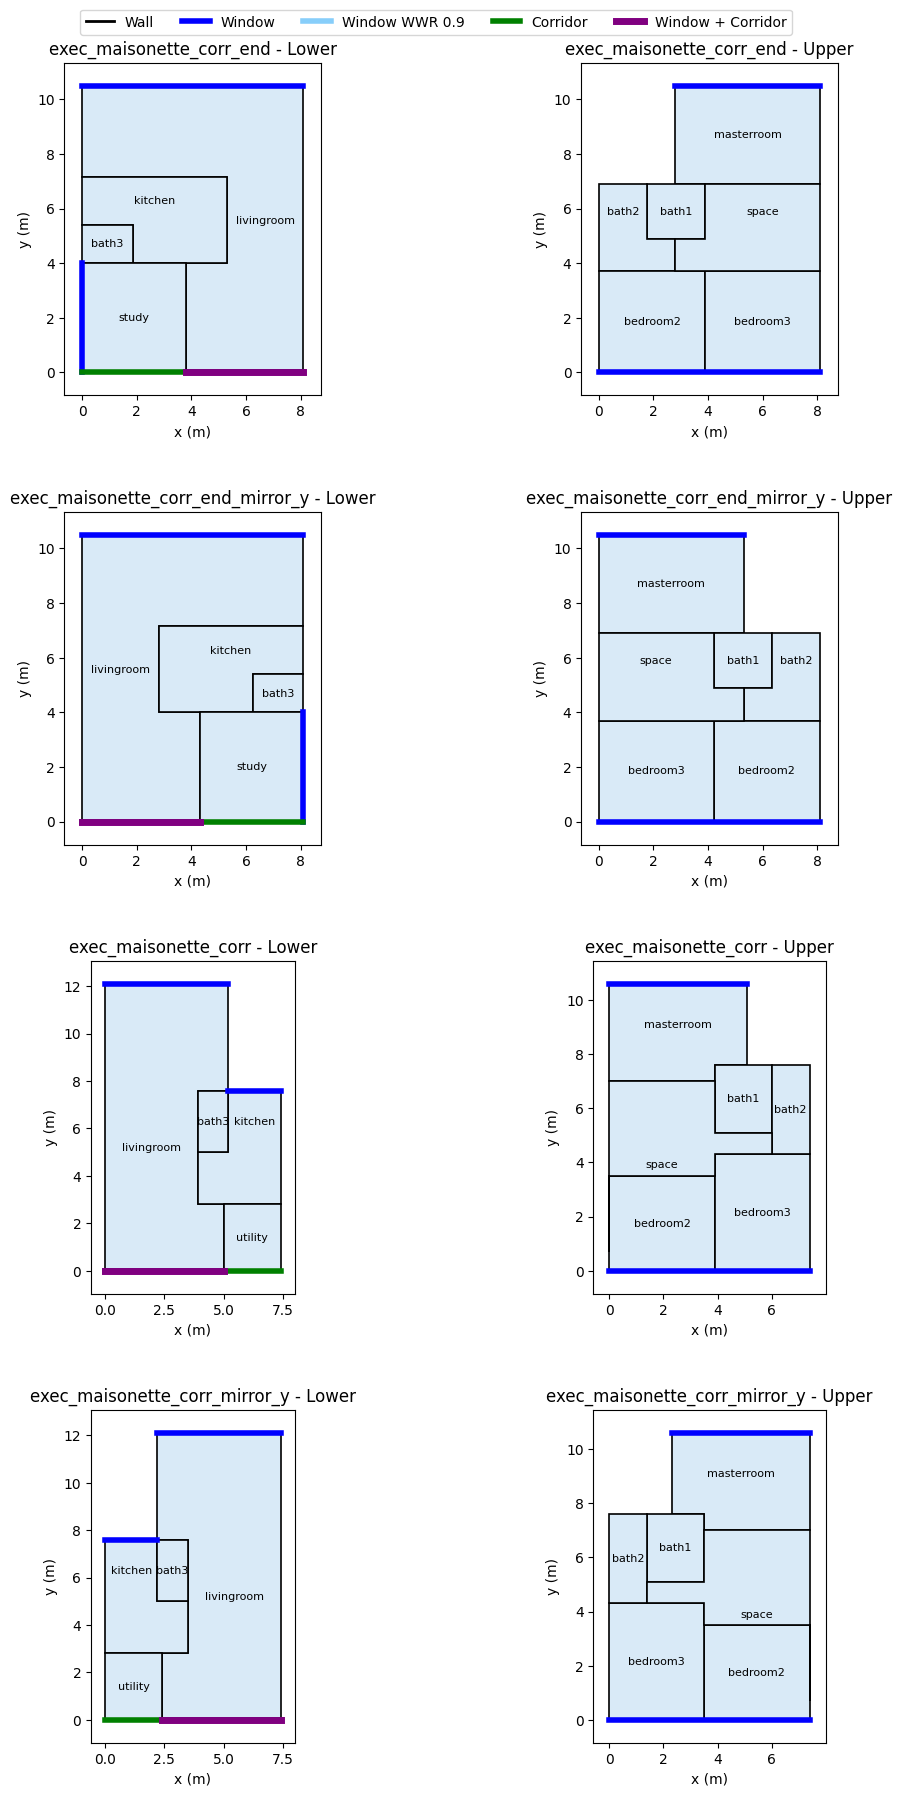

In [19]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon


def facade_points(facade):
    if "points" in facade:
        return facade["points"]
    return [facade["start"], facade["end"]]


def facade_segments(facades, facade_type):
    segments = []

    for facade in facades:
        if facade.get("type", "").lower() != facade_type:
            continue

        points = facade_points(facade)

        for p1, p2 in zip(points[:-1], points[1:]):
            segments.append((p1, p2, facade))

    return segments


def cross(a, b, c):
    return (
        (b[0] - a[0]) * (c[1] - a[1])
        - (b[1] - a[1]) * (c[0] - a[0])
    )


def segment_overlap(segment_a, segment_b, tolerance=1e-9):
    a, b = segment_a
    c, d = segment_b

    vx = b[0] - a[0]
    vy = b[1] - a[1]

    length_squared = vx * vx + vy * vy

    if length_squared <= tolerance:
        return None

    if (
        abs(cross(a, b, c)) > tolerance
        or abs(cross(a, b, d)) > tolerance
    ):
        return None

    wx = d[0] - c[0]
    wy = d[1] - c[1]

    if abs(vx * wy - vy * wx) > tolerance:
        return None

    c_pos = (
        (c[0] - a[0]) * vx
        + (c[1] - a[1]) * vy
    ) / length_squared

    d_pos = (
        (d[0] - a[0]) * vx
        + (d[1] - a[1]) * vy
    ) / length_squared

    start = max(0, min(c_pos, d_pos))
    end = min(1, max(c_pos, d_pos))

    if end - start <= tolerance:
        return None

    return (
        [a[0] + vx * start, a[1] + vy * start],
        [a[0] + vx * end, a[1] + vy * end],
    )


def plot_segment(ax, segment, color, linewidth, zorder):
    (x1, y1), (x2, y2) = segment

    ax.plot(
        [x1, x2],
        [y1, y2],
        color=color,
        linewidth=linewidth,
        zorder=zorder
    )


def plot_level(ax, level, title):

    # Rooms
    for room_name, room in level["rooms"].items():
        coordinates = room["coordinates"]

        ax.add_patch(
            Polygon(
                coordinates,
                closed=True,
                facecolor=(
                    "white"
                    if room_name.lower() == "balcony"
                    else "#d9eaf7"
                ),
                edgecolor="black",
                linewidth=1.2,
                zorder=1
            )
        )

        point = ShapelyPolygon(
            coordinates
        ).representative_point()

        ax.text(
            point.x,
            point.y,
            room_name,
            ha="center",
            va="center",
            fontsize=8,
            zorder=2
        )

    facades = level.get("facades", [])

    window_segments = facade_segments(
        facades,
        "window"
    )

    corridor_segments = facade_segments(
        facades,
        "corridor"
    )

    # Windows
    for p1, p2, facade in window_segments:

        color = (
            "lightskyblue"
            if facade.get("WWR") == 0.9
            else "blue"
        )

        plot_segment(
            ax,
            (p1, p2),
            color,
            4,
            4
        )

    # Corridors
    for p1, p2, _ in corridor_segments:
        plot_segment(
            ax,
            (p1, p2),
            "green",
            4,
            4
        )

    # Window + corridor overlap
    for w1, w2, _ in window_segments:

        for c1, c2, _ in corridor_segments:

            overlap = segment_overlap(
                (w1, w2),
                (c1, c2)
            )

            if overlap:
                plot_segment(
                    ax,
                    overlap,
                    "purple",
                    5,
                    5
                )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.margins(0.08)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")


def plot_EM_templates(json_file):

    with open(
        json_file,
        encoding="utf-8"
    ) as f:
        templates = json.load(f)

    fig, axes = plt.subplots(
        len(templates),
        2,
        figsize=(12, 5 * len(templates)),
        squeeze=False,
        constrained_layout=False
    )

    fig.subplots_adjust(
        top=0.95,
        hspace=0.35,
        wspace=0.25
    )

    for row, (unit_type, unit) in enumerate(
        templates.items()
    ):

        plot_level(
            axes[row, 0],
            unit["lower"],
            f"{unit_type} - Lower"
        )

        plot_level(
            axes[row, 1],
            unit["upper"],
            f"{unit_type} - Upper"
        )

    fig.legend(
        handles=[
            Line2D(
                [0], [0],
                color="black",
                linewidth=2,
                label="Wall"
            ),
            Line2D(
                [0], [0],
                color="blue",
                linewidth=4,
                label="Window"
            ),
            Line2D(
                [0], [0],
                color="lightskyblue",
                linewidth=4,
                label="Window WWR 0.9"
            ),
            Line2D(
                [0], [0],
                color="green",
                linewidth=4,
                label="Corridor"
            ),
            Line2D(
                [0], [0],
                color="purple",
                linewidth=5,
                label="Window + Corridor"
            ),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=5
    )

    plt.show()


plot_EM_templates(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\unittemplates_EM.json"
)